# Heart Disease Prediction — ML Pipeline

This notebook builds a complete machine learning pipeline to predict whether a patient has heart disease based on clinical measurements.

**Dataset:** Cleveland Heart Disease dataset  
**Goal:** Binary classification — predict `target` (0 = No Disease, 1 = Disease Present)  
**Pipeline stages:** Data loading → Inspection → Cleaning → Encoding → Scaling → Feature Engineering → Feature Selection → Outlier Removal → Model Training & Evaluation

---

## 1. Data Loading

In [25]:
#-----------------------------------------
# LOADING THE DATASET
#-----------------------------------------

import pandas as pd

from google.colab import files
uploaded = files.upload()

df = pd.read_csv('heart.csv.xls')
df.head()


Saving heart.csv.xls to heart.csv (1).xls


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## 2. Dataset Inspection

Before any processing, we inspect the dataset's structure — number of rows/columns, data types, and a quick preview of the first few rows.

In [26]:
#-----------------------------------------
# INSPECTING THE DATASET
#-----------------------------------------
print("="*30)
print('INSPECTING THE DATASET')
print("="*30)
print("Info :",df.info())
print("Shape :",df.shape)
print("First 5 rows :")
df.head()



INSPECTING THE DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
Info : None
Shape : (1025, 14)
First 5 rows :


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


# Heart Disease Dataset - Column Reference
| Column | Full Name | Type | Values | Plain English Meaning |
|---|---|---|---|---|
|age|Age|Numeric|29-77|Age of patient in years|
|sex|Sex|Categorical|0 = Female , 1 = Male| Gender of patient|
| cp | Chest Pain Type | Categorical | 0 = typical angina, 1 = atypical angina, 2 = non-anginal pain, 3 = asymptomatic | Type of chest pain the patient experiences |
| trestbps | Resting Blood Pressure | Numeric | continuous (mm Hg) | Blood pressure when the patient is at rest — higher means more strain on heart |
| chol | Serum Cholesterol | Numeric | continuous (mg/dl) | Amount of fat/cholesterol in the blood — higher means more risk |
| fbs | Fasting Blood Sugar | Categorical | 0 = Normal, 1 = High (>120 mg/dl) | Whether the patient's blood sugar is too high after fasting |
| restecg | Resting ECG Results | Categorical | 0 = Normal, 1 = ST-T wave abnormality, 2 = Left ventricular hypertrophy | Heart electrical signal reading while at rest |
| thalach | Max Heart Rate Achieved | Numeric | continuous (bpm) | The highest heart rate the patient reached during a test — higher usually means healthier |
| exang | Exercise Induced Angina | Categorical | 0 = No, 1 = Yes | Does the patient feel chest pain when exercising? |
| oldpeak | ST Depression | Numeric | continuous (float) | How much the heart struggles during exercise compared to rest — higher means worse |
| slope | Slope of ST Segment | Categorical | 0 = Upsloping, 1 = Flat, 2 = Downsloping | Shape of the heart signal during peak exercise |
| ca | Major Vessels Colored | Categorical | 0, 1, 2, 3 | Number of major heart vessels that are blocked — more blocked = more risk |
| thal | Thalassemia | Categorical | 0 = Normal, 1 = Fixed defect, 2 = Reversible defect, 3 = Unknown | Blood flow condition in the heart |
| target | Heart Disease | Binary | 0 = No Disease, 1 = Disease Present | Whether the patient has heart disease or not — this is what we are predicting |

## 3. Column Schema

We separate columns by their statistical type. This distinction drives encoding and scaling decisions later in the pipeline:

- **Numeric** — continuous measurements (age, blood pressure, cholesterol, etc.)
- **Binary** — two-value flags (sex, fasting blood sugar, exercise angina)
- **Ordinal** — ordered categories where the rank matters (slope, number of vessels)
- **Nominal** — unordered categories where no rank exists (chest pain type, ECG result, thalassemia)

In [27]:
#-----------------------------------------
# COLUMN SCHEMA
#-----------------------------------------
numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
binary_cols  = ['sex', 'fbs', 'exang']
ordinal_cols = ['slope', 'ca']
nominal_cols = ['cp', 'restecg', 'thal']
target_col   = 'target'

## 4. Missing Value Check

A quick check for `NaN` values before any cleaning is applied. This gives us a baseline before we run the full data quality audit below.

In [28]:
print("Missing Values :")
df.isna().sum()

Missing Values :


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


## 5. Target Distribution

We inspect whether the dataset is balanced between the two classes. A severe imbalance would require oversampling (e.g. SMOTE) or class-weight adjustments when training models.

target
1    526
0    499
Name: count, dtype: int64


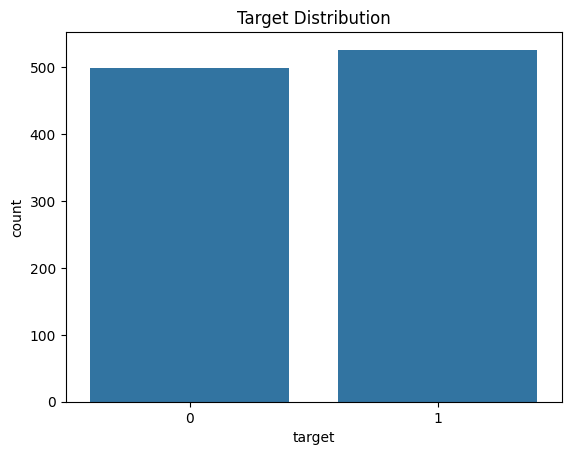

In [29]:
# Target Distribution
import seaborn as sns
import matplotlib.pyplot as plt

print(df['target'].value_counts())

sns.countplot(x='target', data=df)
plt.title('Target Distribution')
plt.show()

## 6. Type Conversion — Numeric → Categorical

Several columns are stored as integers but represent discrete categories with no numeric meaning (e.g. `cp = 2` does not mean "twice as much" as `cp = 1`). We cast these to the `category` dtype so pandas and downstream encoders treat them correctly.

In [30]:
#----------------------------------------------------------------------
# CONVERTING PARTIAL CATEGORICAL COLUMNS INTO COMPLETE CATEGORICAL ONES
#----------------------------------------------------------------------

cat_cols = ['sex' , 'cp' , 'fbs' , 'restecg' , 'exang' , 'slope' , 'ca' , 'thal']

df[cat_cols] = df[cat_cols].astype('category')

df.info()

df


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   age       1025 non-null   int64   
 1   sex       1025 non-null   category
 2   cp        1025 non-null   category
 3   trestbps  1025 non-null   int64   
 4   chol      1025 non-null   int64   
 5   fbs       1025 non-null   category
 6   restecg   1025 non-null   category
 7   thalach   1025 non-null   int64   
 8   exang     1025 non-null   category
 9   oldpeak   1025 non-null   float64 
 10  slope     1025 non-null   category
 11  ca        1025 non-null   category
 12  thal      1025 non-null   category
 13  target    1025 non-null   int64   
dtypes: category(8), float64(1), int64(5)
memory usage: 57.4 KB


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


**sex, cp, fbs, restecg, exang, slope, ca, thal are the categorical columns**
to be more precise these are the categorical columns disguised as integer format so we converted them into object/string type

## 7. Data Quality Audit

We systematically check for five categories of data quality issues:

1. **Duplicate rows** — identical records that could bias the model
2. **Missing values** — explicit `NaN` fields
3. **Hidden nulls** — zeros in columns where zero is physiologically impossible (e.g. cholesterol of 0)
4. **Range validity** — values outside clinically plausible bounds
5. **Categorical validity** — category codes outside the expected set of values

In [31]:
#-----------------------------------------
# DATA QUALITY ISSUES
#-----------------------------------------

# 1. Duplicate values
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()
print("Shape after dropping duplicates:",df.shape)

# 2. Missing Values
print("\nMissing values:")
print(df.isna().sum())
df = df.dropna()
print("Shape after dropping missing values:",df.shape)

# 3. Hidden Nulls (zeros that shouldn't be zero)
cols_cant_be_zero = ['trestbps', 'chol', 'thalach']
print("\nHidden nulls (zero values in critical columns):")
print((df[cols_cant_be_zero] == 0).sum())

# 4. Validity Check (expected value ranges)
print("\nValidity Checks:")
print("age out of range:", ((df['age'] < 1) | (df['age'] > 120)).sum())
print("trestbps out of range (< 50 or > 250):", ((df['trestbps'] < 50) | df['trestbps'] > 250).sum())
print("chol out of range (< 100 or > 600):", ((df['chol'] < 100) | (df['chol'] > 600)).sum())
print("thalach out of range (< 50 or > 250):", ((df['thalach'] < 50) | (df['thalach'] > 250)).sum())

# 5. Categorical Validity (only expected values)
print("\nUnexpected values in categorical columns:")
expected = {'sex': [0,1], 'cp': [0,1,2,3], 'fbs': [0,1],
            'restecg': [0,1,2], 'exang': [0,1],
            'slope': [0,1,2], 'ca': [0,1,2,3], 'thal': [0,1,2,3]}

for col, valid in expected.items():
    unexpected = ~df[col].isin(valid)
    print(f"{col}: {unexpected.sum()} unexpected values")

Duplicate rows: 723
Shape after dropping duplicates: (302, 14)

Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64
Shape after dropping missing values: (302, 14)

Hidden nulls (zero values in critical columns):
trestbps    0
chol        0
thalach     0
dtype: int64

Validity Checks:
age out of range: 0
trestbps out of range (< 50 or > 250): 0
chol out of range (< 100 or > 600): 0
thalach out of range (< 50 or > 250): 0

Unexpected values in categorical columns:
sex: 0 unexpected values
cp: 0 unexpected values
fbs: 0 unexpected values
restecg: 0 unexpected values
exang: 0 unexpected values
slope: 0 unexpected values
ca: 4 unexpected values
thal: 0 unexpected values


**Data Quality issues**


### Fixing Invalid Category in `ca`

The `ca` column (number of major vessels colored) has valid values 0–3. Any value of `4` is invalid and is treated as missing. We replace it with the column's mode (most common value).

In [32]:
import numpy as np
df['ca'] = df['ca'].replace(4 , np.nan)
df['ca'] = df['ca'].fillna(df['ca'].mode()[0])
print(df['ca'].value_counts())

ca
0    179
1     65
2     38
3     20
Name: count, dtype: int64


/tmp/ipykernel_22891/3133471528.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df['ca'] = df['ca'].replace(4 , np.nan)


## 8. Train / Test Split

We split the cleaned dataset into training (80%) and test (20%) sets before any encoding or scaling. This is critical — all transformations must be **fit on `X_train` only** and then applied to `X_test`, preventing data leakage.

In [33]:
#-----------------------------------------
# SPITTING THE DATA INTO TEST, TRAIN
#-----------------------------------------

from sklearn.model_selection import train_test_split

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (241, 13)
Shape of X_test: (61, 13)
Shape of y_train: (241,)
Shape of y_test: (61,)


## 9. Categorical Encoding

Categorical columns cannot be passed directly to most ML algorithms. We encode them based on their type:

- **Nominal columns** (`cp`, `restecg`, `thal`) → **One-Hot Encoding** — creates binary dummy columns; `drop='first'` removes one column per group to avoid multicollinearity
- **Ordinal columns** (`slope`, `ca`) → **Ordinal Encoding** — preserves the natural rank order with integer codes

Encoders are fit **only on `X_train`** to prevent test data leakage, then applied to both splits.

In [34]:
#-----------------------------------------
# HANDLING CATEGORICAL COLUMNS
#-----------------------------------------

cat_cols = X_train.select_dtypes(include="category").columns
print("Columns and their unique number of elements : ")
print(X_train[cat_cols].nunique())

#----------------------------------------------------------
# SPITTING THE CAT COLUMNS INTO THEIR RESPECTIVE CATEGORIES
#----------------------------------------------------------

ordinal_cols = ['slope' , 'ca']
nominal_cols = ['cp' , 'restecg' , 'thal']

from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder
ohe = OneHotEncoder(drop="first")
oe = OrdinalEncoder(categories=[[0,1,2] , [0,1,2,3]])

ohe_apply = ohe.fit_transform(X_train[nominal_cols]) # You should apply encoding on X_train to avoid test data leakage if we use df instead of X_train
oe_apply = oe.fit_transform(X_train[ordinal_cols])   # data leakage occurs

#----------------------------------------------------------
# COMBINING EVERY ENCODED COLUMN INTO A SINGLE DATAFRAME
#----------------------------------------------------------

ohe_df = pd.DataFrame(ohe_apply.toarray() , columns=ohe.get_feature_names_out())
oe_df = pd.DataFrame(oe_apply, columns=ordinal_cols)
X_train.drop(nominal_cols , axis=1 , inplace=True)
X_train.drop(ordinal_cols , axis=1 , inplace=True)
X_train = X_train.reset_index(drop=True)
ohe_df = ohe_df.reset_index(drop=True)
oe_df = oe_df.reset_index(drop=True)
X_train = pd.concat([X_train , ohe_df , oe_df] , axis=1)

X_train.head()


Columns and their unique number of elements : 
sex        2
cp         4
fbs        2
restecg    3
exang      2
slope      3
ca         4
thal       4
dtype: int64


,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,cp_1,cp_2,cp_3,restecg_1,restecg_2,thal_1,thal_2,thal_3,slope,ca
0,48,1,124,274,0,166,0,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
1,58,1,128,259,0,130,1,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0
2,45,0,130,234,0,175,0,0.6,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,44,1,120,220,0,170,0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0
4,62,0,150,244,0,154,1,1.4,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0


## 10. Scaling

Numeric features span very different ranges. Without scaling, distance-based and gradient-based algorithms will be dominated by large-magnitude columns.

- **`age`** — roughly normally distributed → `StandardScaler` (zero mean, unit variance)
- **`trestbps`, `chol`, `thalach`, `oldpeak`** — right-skewed / contain outliers → `RobustScaler` (uses median and IQR, resistant to outliers)

Again, scalers are fit on `X_train` only.

Identifing the skewed columns
age        -0.179297
trestbps    0.876227
chol        1.130530
thalach    -0.508218
oldpeak     1.168053
dtype: float64


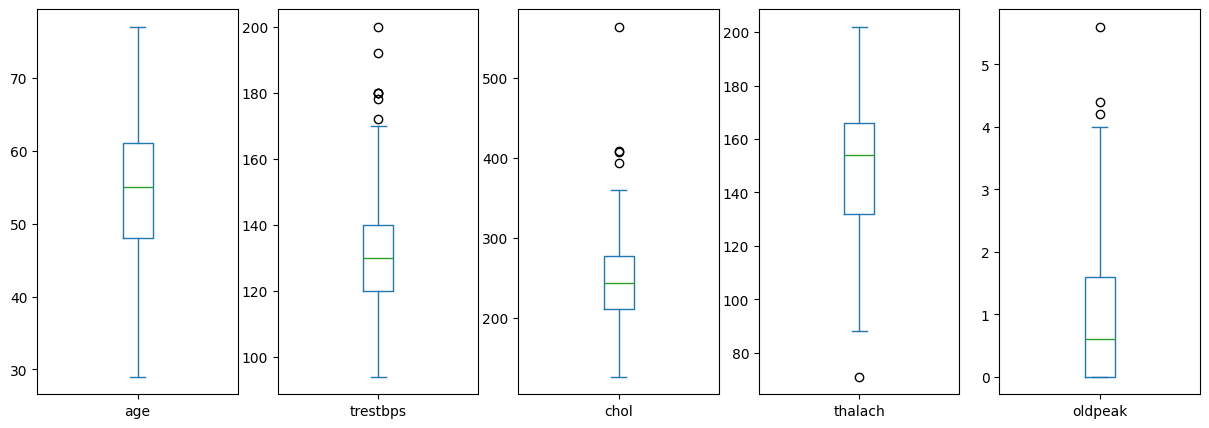

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,cp_1,cp_2,cp_3,restecg_1,restecg_2,thal_1,thal_2,thal_3,slope,ca
0,-0.682633,1,-0.3,0.469697,0,0.352941,0,-0.0625,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
1,0.403989,1,-0.1,0.242424,0,-0.705882,1,1.5000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0
2,-1.008619,0,0.0,-0.136364,0,0.617647,0,0.0000,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,-1.117282,1,-0.5,-0.348485,0,0.470588,0,-0.3750,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0
4,0.838637,0,1.0,0.015152,0,0.000000,1,0.5000,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0


In [35]:
#-----------------------------------------
# STANDARDIZATION / NORMALISATION
#-----------------------------------------
print("Identifing the skewed columns")
print(X_train[numeric_cols].skew())

X_train[numeric_cols].plot(kind='box', subplots=True, figsize=(15,5))
plt.show()

rob_cols = ['trestbps' , 'chol' , 'thalach' , 'oldpeak']

from sklearn.preprocessing import StandardScaler,RobustScaler
scal1 = StandardScaler()
scal2 = RobustScaler()

scal1_apply = scal1.fit_transform(X_train[['age']])
scal2_apply = scal2.fit_transform(X_train[rob_cols])

#-----------------------------------------
# Scaled values back into X_train
#-----------------------------------------
X_train['age'] = scal1_apply
X_train[rob_cols] = scal2_apply

X_train.head()

## 11. Feature Engineering

We construct three interaction features that capture clinically meaningful relationships not directly expressed by individual columns:

| New Feature | Formula | Intuition |
|---|---|---|
| `chol_bp_risk` | `chol × trestbps` | Combined cardiovascular load |
| `heart_stress_ratio` | `thalach / (oldpeak + 1)` | Heart capacity vs. stress response |
| `age_heart_rate_ratio` | `age / (thalach + 1)` | Age-adjusted heart rate efficiency |

In [36]:
#-----------------------------------------
# CONSTRUCTING NEW FEATURES
#-----------------------------------------

X_train['chol_bp_risk'] = X_train['chol'] * X_train['trestbps']
X_train['heart_stress_ratio'] = X_train['thalach'] / (X_train['oldpeak'] + 1)
X_train['age_heart_rate_ratio'] = X_train['age'] / (X_train['thalach'] + 1)

X_train.head()
#

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,cp_1,cp_2,...,restecg_1,restecg_2,thal_1,thal_2,thal_3,slope,ca,chol_bp_risk,heart_stress_ratio,age_heart_rate_ratio
0,-0.682633,1,-0.3,0.469697,0,0.352941,0,-0.0625,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,-0.140909,0.376471,-0.504555
1,0.403989,1,-0.1,0.242424,0,-0.705882,1,1.5000,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,2.0,-0.024242,-0.282353,1.373562
2,-1.008619,0,0.0,-0.136364,0,0.617647,0,0.0000,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,-0.000000,0.617647,-0.623510
3,-1.117282,1,-0.5,-0.348485,0,0.470588,0,-0.3750,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,2.0,0.0,0.174242,0.752941,-0.759751
4,0.838637,0,1.0,0.015152,0,0.000000,1,0.5000,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.015152,0.000000,0.838637


## 12. Feature Selection

With encoding and engineering complete, we use both **Filter** and **Wrapper** methods to select the most predictive features and reduce dimensionality.

### 12a. Filter Methods

**Correlation** measures linear association between each numeric feature and the target. Features with `|correlation| > 0.05` are considered relevant.

**Chi-Square** tests the statistical dependence between each categorical feature and the target. Higher scores indicate stronger association.

In [37]:
#-----------------------------------------
# CONSTRUCTING NEW FEATURES
#-----------------------------------------

# 1).FILTER METHODS

# CORRELATION OF FEATURES

corr_df = pd.concat([X_train[numeric_cols],y_train],axis = 1)

corr_scores = (
    corr_df.corr()["target"]
    .drop("target")
    .abs()
    .sort_values(ascending=False)
)
selct = corr_scores[corr_scores > 0.05]
print("-"*45)
print('Correlation scores of all the features:')
print("-"*45)
print(corr_scores)
print("-"*50)
print("Features with Correlation score greater than 0.05:")
print("-"*50)
print(selct)

# CHI-SQUARE

from sklearn.feature_selection import SelectKBest, chi2

# Extracting all the categorical columns
chi2_cols = ['cp_1', 'cp_2', 'cp_3',
             'restecg_1', 'restecg_2',
             'thal_1', 'thal_2', 'thal_3',
             'slope', 'ca',
             'sex', 'fbs', 'exang']
selector = SelectKBest(chi2, k='all')
X_train_chi2 = selector.fit_transform(X_train[chi2_cols], y_train)
chi2_scores = pd.Series(selector.scores_,index=chi2_cols)
chi2_scores.sort_values(ascending=False,inplace=True)
print("-"*50)
print('Chi-square scores of all the features:')
print("-"*50)
print(chi2_scores)

---------------------------------------------
Correlation scores of all the features:
---------------------------------------------
chol        0.202396
oldpeak     0.175711
age         0.106949
trestbps    0.026073
thalach     0.011138
Name: target, dtype: float64
--------------------------------------------------
Features with Correlation score greater than 0.05:
--------------------------------------------------
chol       0.202396
oldpeak    0.175711
age        0.106949
Name: target, dtype: float64
--------------------------------------------------
Chi-square scores of all the features:
--------------------------------------------------
ca           62.958877
thal_3       37.973452
thal_2       34.886386
exang        30.771660
cp_2         20.156243
cp_1         10.729110
slope         9.587721
sex           8.809808
thal_1        6.391011
restecg_1     5.662451
restecg_2     1.561862
cp_3          1.465076
fbs           0.326848
dtype: float64


### Fixing Infinite Values

The engineered feature `age_heart_rate_ratio` can produce `inf` if `thalach + 1` evaluates to zero after scaling. We replace any `inf` values with the column median before proceeding.

In [38]:
import numpy as np
print(np.isinf(X_train.select_dtypes(include='number')).sum())
X_train['age_heart_rate_ratio'] = X_train['age_heart_rate_ratio'].replace([np.inf, -np.inf], np.nan)
X_train['age_heart_rate_ratio'] = X_train['age_heart_rate_ratio'].fillna(X_train['age_heart_rate_ratio'].median())

age                     0
trestbps                0
chol                    0
thalach                 0
oldpeak                 0
cp_1                    0
cp_2                    0
cp_3                    0
restecg_1               0
restecg_2               0
thal_1                  0
thal_2                  0
thal_3                  0
slope                   0
ca                      0
chol_bp_risk            0
heart_stress_ratio      0
age_heart_rate_ratio    2
dtype: int64


### 12b. Wrapper Method — RFE (Recursive Feature Elimination)

RFE fits a Logistic Regression model and iteratively removes the least important feature until the desired number remains. We select the top **10 features** based on model-derived importance, which accounts for feature interactions that filter methods miss.

In [39]:
# 2. WRAPPER METHODS

from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

rfe = RFE(estimator=lr, n_features_to_select=10)
rfe.fit(X_train, y_train)

selected = X_train.columns[rfe.support_]
print("-"*50)
print('Selected features by RFE:')
print("-"*50)
print(selected)



--------------------------------------------------
Selected features by RFE:
--------------------------------------------------
Index(['sex', 'thalach', 'oldpeak', 'cp_1', 'cp_2', 'cp_3', 'restecg_1',
       'thal_2', 'slope', 'ca'],
      dtype='object')


We now trim `X_train` down to only the 10 selected features.

In [40]:
X_train = X_train[selected]
print(X_train.shape)
print(X_train.dtypes)

(241, 10)
sex          category
thalach       float64
oldpeak       float64
cp_1          float64
cp_2          float64
cp_3          float64
restecg_1     float64
thal_2        float64
slope         float64
ca            float64
dtype: object


## Feature Extraction (PCA) — Not Applied

After feature selection, the remaining 10 features consist mostly of
binary and ordinal encoded categorical columns. PCA is designed for
continuous numeric data and applying it on binary/ordinal columns
would distort their categorical meaning.

Only 2 truly continuous columns remain (thalach, oldpeak) —
applying PCA on just 2 columns is not meaningful.

**Conclusion: PCA is not applicable for this dataset after feature selection.**

## Feature Extraction (SVD) — Not Applied

TruncatedSVD is typically used for:
- High dimensional sparse data (text, large one-hot encoded matrices)
- Datasets too large to fit in memory
- Matrix factorization problems

Our dataset does not meet these criteria:
- Small dataset (241 rows × 10 columns)
- Dense matrix (no sparse data)
- Tabular structured data

PCA internally uses SVD for its calculations — so SVD is already
being leveraged under the hood when PCA is applied.

**Conclusion: Explicit SVD is not applicable for this dataset.**

## 13. Outlier Detection

We use two unsupervised outlier detection methods and remove only the rows flagged by **both** — a conservative ensemble approach that reduces false positives.

- **LOF (Local Outlier Factor)** — detects outliers based on local density; a point is an outlier if its neighborhood is significantly denser than its own region
- **KNN distance score** — flags points whose distance to their k-th nearest neighbor exceeds the 95th percentile threshold

Only rows confirmed by **both** methods are removed.

In [41]:
#-----------------------------------------
# OUTLIER DETECTION
#-----------------------------------------
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
pred = lof.fit_predict(X_train)

print("Outliers detected:", (pred == -1).sum())
print("Normal points:", (pred == 1).sum())

Outliers detected: 12
Normal points: 229


In [42]:
# USING KNN

from sklearn.neighbors import NearestNeighbors
import numpy as np

k = 20  # same as LOF

# Create model
nbrs = NearestNeighbors(n_neighbors=k)

# Fit model
nbrs.fit(X_train)

# Get distances and neighbor indices
distances, indices = nbrs.kneighbors(X_train)

# Use distance to kth nearest neighbor as anomaly score
knn_score = distances[:, -1]

# Threshold using 95th percentile
threshold = np.percentile(knn_score, 95)

# Flag outliers
outliers = knn_score > threshold

print("KNN Outliers detected:", outliers.sum())
print("KNN Normal points:", (~outliers).sum())

KNN Outliers detected: 12
KNN Normal points: 229


In [43]:
lof_outliers = pred == -1
knn_outliers = outliers

# Rows flagged by BOTH
both_outliers = lof_outliers & knn_outliers
print("Confirmed outliers (flagged by both):", both_outliers.sum())

Confirmed outliers (flagged by both): 6


In [44]:
X_train = X_train[~both_outliers]
y_train = y_train[~both_outliers]

print("X_train shape after outlier removal:", X_train.shape)
print("y_train shape after outlier removal:", y_train.shape)

X_train shape after outlier removal: (235, 10)
y_train shape after outlier removal: (235,)


## 14. Applying the Same Transformations to `X_test`

We now apply — in the exact same order — all transformations that were fit on `X_train`:
1. Encode categorical columns using the already-fitted `ohe` and `oe` objects
2. Construct the same engineered features
3. Handle any infinite values
4. Scale using the already-fitted `scal1` and `scal2`
5. Select the same features chosen by RFE

> ⚠️ Note: Outlier removal is **not** applied to `X_test`. We evaluate the model on the full test set including borderline cases.

In [45]:
#-----------------------------------------
# APPLYING TRANSFORMATIONS ON X_test
#-----------------------------------------

# 1. ENCODING

# APPLYING THE OBJECT FROM ENCODING CELL
ohe_test = ohe.transform(X_test[nominal_cols])
oe_test = oe.transform(X_test[ordinal_cols])

ohe_test_df = pd.DataFrame(ohe_test.toarray() , columns=ohe.get_feature_names_out())
oe_test_df = pd.DataFrame(oe_test, columns=ordinal_cols)

# DROPPING DOWN THE ORIGINAL CAT COLUMNS
X_test = X_test.drop(nominal_cols, axis=1)
X_test = X_test.drop(ordinal_cols, axis=1)
X_test = X_test.reset_index(drop=True)
ohe_test_df = ohe_test_df.reset_index(drop=True)
oe_test_df = oe_test_df.reset_index(drop=True)

# CONCATENATING THE ENCODED COLUMNS
X_test = pd.concat([X_test, ohe_test_df, oe_test_df], axis=1)

# FEATURE CONSTRUCTION
X_test['chol_bp_risk'] = X_test['chol']*X_test['trestbps']
X_test['heart_stress_ratio'] = X_test['thalach']/(X_test['oldpeak']+1)
X_test['age_heart_rate_ratio']=X_test['age']/(X_test['thalach']+1)

X_test['age_heart_rate_ratio']=X_test['age_heart_rate_ratio'].replace([np.inf , -np.inf] , np.nan)
X_test['age_heart_rate_ratio'] = X_test['age_heart_rate_ratio'].fillna(X_test['age_heart_rate_ratio'].median())

# 3. SCALING
X_test[['age']] = scal1.transform(X_test[['age']])
X_test[rob_cols] = scal2.transform(X_test[rob_cols])

# 4. FEATURE SELECTION
X_test = X_test[selected]

print("X_test shape:", X_test.shape)


X_test shape: (61, 10)


## 15. Model Training & Evaluation

We train three classifiers and compare their performance. All models are trained on the preprocessed `X_train` and evaluated on `X_test`.

### 15a. Logistic Regression

A linear probabilistic classifier — a strong baseline for binary classification tasks.

In [46]:
#-----------------------------------------
# LOGISTIC REGRESSION
#-----------------------------------------
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

lr = LogisticRegression()
lr.fit(X_train , y_train)

y_pred = lr.predict(X_test)
# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7540983606557377

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.66      0.74        32
           1       0.69      0.86      0.77        29

    accuracy                           0.75        61
   macro avg       0.77      0.76      0.75        61
weighted avg       0.77      0.75      0.75        61


Confusion Matrix:
[[21 11]
 [ 4 25]]


### 15b. Random Forest

An ensemble of decision trees trained with bagging and random feature subsets. Generally more robust than a single tree and handles non-linear relationships well.

In [47]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Results:
Accuracy: 0.7540983606557377

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.69      0.75        32
           1       0.71      0.83      0.76        29

    accuracy                           0.75        61
   macro avg       0.76      0.76      0.75        61
weighted avg       0.76      0.75      0.75        61


Confusion Matrix:
[[22 10]
 [ 5 24]]


### 15c. Decision Tree

A single tree that learns explicit decision rules. Interpretable but prone to overfitting without pruning.

In [48]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("Decision Tree Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

Decision Tree Results:
Accuracy: 0.7213114754098361

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.72      0.73        32
           1       0.70      0.72      0.71        29

    accuracy                           0.72        61
   macro avg       0.72      0.72      0.72        61
weighted avg       0.72      0.72      0.72        61


Confusion Matrix:
[[23  9]
 [ 8 21]]


## 16. Model Comparison

We summarise the accuracy of all three models and identify the best-performing one.

In [49]:
results = {
    "Logistic Regression": accuracy_score(y_test, y_pred),
    "Random Forest": accuracy_score(y_test, y_pred_rf),
    "Decision Tree": accuracy_score(y_test, y_pred_dt)
}

print("="*40)
print("MODEL COMPARISON")
print("="*40)
for model, acc in results.items():
    print(f"{model}: {acc:.4f}")

best_model = max(results, key=results.get)
print(f"\nBest Model: {best_model}")

MODEL COMPARISON
Logistic Regression: 0.7541
Random Forest: 0.7541
Decision Tree: 0.7213

Best Model: Logistic Regression
